In [1]:
import sys, re, json
sys.path.append('..') 

from scripts.constants import *
from scripts.utils import *
from scripts.sedona_config import *

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
project_crs = 'EPSG:27700'

T3_30_300_DIR = VECTOR_OUT_DIR / "3-30-300"
T3_dir = T3_30_300_DIR / "T3"
T30_dir = T3_30_300_DIR / "T30"
T300_dir = T3_30_300_DIR / "T300"
t3_30_300_path = T3_30_300_DIR / "T3_30_300.geojson"
imd_lsoa_bua_boundaries_path = VECTOR_OUT_DIR / "IMD" / "English_IMD_2019_BUA_filtered_boundaries.geojson"
imd_england_path = VECTOR_IN_DIR / "IMD" / "English IMD 2019" / "IMD_2019.shp"
buildings_path = VECTOR_IN_DIR / "EDINA" / "Buildings_6183" / "Buildings_6183.parquet"

In [3]:
geo_level = 'LAD22CD'
geo_code = 'E07000008'
imd_lsoa_bua_gdf = gpd.read_file(imd_lsoa_bua_boundaries_path)
geo_level_codes = imd_lsoa_bua_gdf[geo_level].unique()
imd_england_columns = ['lsoa11cd', 'TotPop', 'DepChi', 'Pop16_59', 'Pop60+', 'WorkPop',
                       'IMD_Rank', 'IMD_Decile', 'IMDScore', 'IncScore', 'IncRank', 'IncDec', 
                       'EmpScore', 'EmpRank', 'EmpDec', 'EduScore', 'EduRank', 'EduDec', 
                       'HDDScore', 'HDDRank', 'HDDDec', 'CriScore', 'CriRank', 'CriDec', 
                       'BHSScore', 'BHSRank', 'BHSDec', 'EnvScore', 'EnvRank', 'EnvDec']
imd_england_gdf = gpd.read_file(imd_england_path)[imd_england_columns]

In [4]:
os.environ["JAVA_HOME"] = JAVA_HOME
sedona = get_spark()

25/01/24 17:29:42 WARN Utils: Your hostname, kinabalu resolves to a loopback address: 127.0.1.1; using 128.232.93.1 instead (on interface eno12399np0)
25/01/24 17:29:42 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
https://artifacts.unidata.ucar.edu/repository/unidata-all added as a remote repository with the name: repo-1
Ivy Default Cache set to: /home/acz25/.ivy2/cache
The jars for the packages stored in: /home/acz25/.ivy2/jars
org.apache.sedona#sedona-spark-3.5_2.12 added as a dependency
org.datasyslab#geotools-wrapper added as a dependency
net.postgis#postgis-jdbc added as a dependency
net.postgis#postgis-geometry added as a dependency
org.postgresql#postgresql added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-db61c2c3-4629-4538-8e11-0656258a16ed;1.0
	confs: [default]


:: loading settings :: url = jar:file:/maps-priv/maps/acz25/miniconda3/envs/3-30-300-env/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found org.apache.sedona#sedona-spark-3.5_2.12;1.7.0 in central
	found org.apache.sedona#sedona-common;1.7.0 in central
	found org.apache.commons#commons-math3;3.6.1 in central
	found org.locationtech.jts#jts-core;1.20.0 in central
	found org.wololo#jts2geojson;0.16.1 in central
	found org.locationtech.spatial4j#spatial4j;0.8 in central
	found com.google.geometry#s2-geometry;2.0.0 in central
	found com.google.guava#guava;25.1-jre in central
	found com.google.code.findbugs#jsr305;3.0.2 in central
	found org.checkerframework#checker-qual;2.0.0 in central
	found com.google.errorprone#error_prone_annotations;2.1.3 in central
	found com.google.j2objc#j2objc-annotations;1.1 in central
	found org.codehaus.mojo#animal-sniffer-annotations;1.14 in central
	found com.uber#h3;4.1.1 in central
	found net.sf.geographiclib#GeographicLib-Java;1.52 in central
	found com.github.ben-manes.caffeine#caffeine;2.9.2 in central
	found org.checkerframework#checker-qual;3.10.0 in central
	found com.google.error

In [5]:
boundaries_sdf = sedona.createDataFrame(imd_lsoa_bua_gdf.drop(columns=['LSOA21NMW', 'LAD22NMW', 'BUA22NMG', 'BUA22NMW', 'RGN22NMW'], axis=1))
boundaries_sdf.createOrReplaceTempView('boundaries')
imd_england_sdf = sedona.createDataFrame(imd_england_gdf)
imd_england_sdf.createOrReplaceTempView('imd_england')
buildings_sdf = sedona.read.format("geoparquet").load(str(buildings_path))
buildings_sdf.createOrReplaceTempView("buildings")

In [6]:
t3_sdf = sedona.read.csv(str(T3_dir), header=True, inferSchema=True)
t3_sdf.createOrReplaceTempView("t3")
t30_sdf = sedona.read.csv(str(T30_dir), header=True, inferSchema=True)
t30_sdf.createOrReplaceTempView("t30")
t300_sdf = sedona.read.csv(str(T300_dir), header=True, inferSchema=True)
t300_sdf.createOrReplaceTempView("t300")

In [7]:
# Perform spatial join
buildings_lsoa_sdf = sedona.sql(
    """
    SELECT b.*, l.LSOA11CD
    FROM buildings b
    JOIN boundaries l
    ON ST_Contains(l.geometry, b.geometry)
    """
)
buildings_lsoa_sdf.createOrReplaceTempView("buildings")

In [8]:
buildings_sdf.groupBy("map_use").count().orderBy("count", ascending=False).show()

24/12/13 15:17:46 WARN GeoParquetFileFormat: GeoParquet currently does not support vectorized reader. Falling back to parquet-mr
24/12/13 15:17:46 WARN GeoParquetFileFormat: GeoParquet currently does not support vectorized reader. Falling back to parquet-mr
24/12/13 15:17:46 WARN GeoParquetFileFormat: GeoParquet currently does not support vectorized reader. Falling back to parquet-mr
24/12/13 15:17:46 WARN GeoParquetFileFormat: GeoParquet currently does not support vectorized reader. Falling back to parquet-mr
24/12/13 15:17:46 WARN GeoParquetFileFormat: GeoParquet currently does not support vectorized reader. Falling back to parquet-mr
24/12/13 15:17:46 WARN GeoParquetFileFormat: GeoParquet currently does not support vectorized reader. Falling back to parquet-mr
24/12/13 15:17:46 WARN GeoParquetFileFormat: GeoParquet currently does not support vectorized reader. Falling back to parquet-mr
24/12/13 15:17:46 WARN GeoParquetFileFormat: GeoParquet currently does not support vectorized rea

+--------------------+--------+
|             map_use|   count|
+--------------------+--------+
|         Residential|24697879|
|             Unknown| 1141942|
|        Agricultural|  828528|
|Commercial - mixe...|  798021|
|Recreation and le...|  297022|
|Retail below offi...|  247084|
|            Industry|  184183|
|              Retail|  175795|
|         Educational|  167665|
|              Office|   72740|
|           Religious|   67110|
|Institutional acc...|   43958|
|           Utilities|   37985|
|           Transport|   35858|
|              Health|   35365|
|        Unclassified|   24669|
|         Complex use|   15604|
|        Governmental|   14061|
|Residential with ...|   11000|
|Commercial - dere...|   10424|
+--------------------+--------+
only showing top 20 rows



In [16]:
t30_imd_lsoa_sdf = sedona.sql(
    """
    SELECT b.*, ROUND(ST_Area(b.geometry), 2) AS area, i.*, t.canopy_cover
    FROM boundaries b
    LEFT JOIN imd_england i ON b.LSOA11CD = i.lsoa11cd
    LEFT JOIN t30 t ON b.LSOA11CD = t.LSOA11CD
    """
)
t30_imd_lsoa_sdf.createOrReplaceTempView("t30_imd_lsoa")
t30_imd_lsoa_sdf.show()

+---------+--------------------+---------+--------------------+---------+--------------------+---------+--------------------+---------+-------+--------------------+---------+---------+------+------+--------+------+-------+--------+----------+--------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+------------+
| LSOA11CD|            LSOA11NM| LSOA21CD|            LSOA21NM|  LAD22CD|             LAD22NM|  BUA22CD|             BUA22NM|  RGN22CD|RGN22NM|            geometry|     area| lsoa11cd|TotPop|DepChi|Pop16_59|Pop60+|WorkPop|IMD_Rank|IMD_Decile|IMDScore|IncScore|IncRank|IncDec|EmpScore|EmpRank|EmpDec|EduScore|EduRank|EduDec|HDDScore|HDDRank|HDDDec|CriScore|CriRank|CriDec|BHSScore|BHSRank|BHSDec|EnvScore|EnvRank|EnvDec|canopy_cover|
+---------+--------------------+---------+--------------------+---------+--------------------+---------+--------------------+---------

In [10]:
t3_300_building_sdf = sedona.sql(
    """
    SELECT b.*, t3.tree_count, t300.closest_park_access_id, t300.distance
    FROM buildings b
    LEFT JOIN t3 ON b.verisk_premise_id = t3.verisk_premise_id
    LEFT JOIN t300 ON b.verisk_premise_id = t300.verisk_premise_id
    """
)
t3_300_building_sdf.createOrReplaceTempView("t3_300_building")
t3_300_building_sdf.show()

24/12/13 15:18:17 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.


+-------------+-----------------+--------------+------+---------------+--------------------+-------------------+--------------------+--------------------+------------+------------------+-----------------+--------------------+---------+----------+----------------------+--------+
|building_area|distance_building|distance_water|height| map_simple_use|             map_use|premise_floor_count|        premise_type|         premise_use|premise_year|verisk_building_id|verisk_premise_id|            geometry| LSOA11CD|tree_count|closest_park_access_id|distance|
+-------------+-----------------+--------------+------+---------------+--------------------+-------------------+--------------------+--------------------+------------+------------------+-----------------+--------------------+---------+----------+----------------------+--------+
|        110.2|              0.0|         447.4|   8.1|    Residential|         Residential|                  2|       Semi-detached|         Residential|        N

In [11]:
t3_300_lsoa_sdf = sedona.sql(
    """
    SELECT LSOA11CD, ROUND(AVG(tree_count), 2) as tree_count, ROUND(AVG(distance), 2) as park_distance
    FROM t3_300_building
    GROUP BY LSOA11CD
    """
)

t3_300_lsoa_sdf.createOrReplaceTempView("t3_300_lsoa")
t3_300_lsoa_sdf.show()

24/12/13 15:19:08 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.


+---------+----------+-------------+
| LSOA11CD|tree_count|park_distance|
+---------+----------+-------------+
|E01029873|      NULL|      2141.94|
|E01026615|      NULL|      1981.59|
|E01026048|      NULL|     Infinity|
|E01022207|      NULL|      6844.61|
|E01023494|      NULL|      3440.36|
|E01031876|      NULL|      3456.38|
|E01027281|      NULL|       655.67|
|E01027633|      NULL|      6460.16|
|E01027571|      NULL|      4335.07|
|E01012927|      NULL|      1130.55|
|E01031630|      NULL|       399.14|
|E01019498|      NULL|       337.37|
|E01017869|      NULL|      1743.83|
|E01012567|      NULL|        472.8|
|E01031518|      NULL|     Infinity|
|E01020314|      NULL|     Infinity|
|E01028794|      NULL|      3429.28|
|E01019607|      NULL|      3936.35|
|E01024347|      NULL|      2844.73|
|E01013256|      NULL|       447.94|
+---------+----------+-------------+
only showing top 20 rows



In [17]:
t3_30_300_sdf = t30_imd_lsoa_sdf.join(t3_300_lsoa_sdf, on="LSOA11CD", how="inner")
t3_30_300_sdf = t3_30_300_sdf.drop("lsoa11cd")
t3_30_300_sdf.createOrReplaceTempView("t3_30_300")
t3_30_300_sdf = sedona.sql(
    """
    SELECT *, (TotPop / area) AS TotPop_density,
    (DepChi / TotPop) AS DepChi_ratio,
    (Pop16_59 / TotPop) AS Pop16_59_ratio,
    (`Pop60+` / TotPop) AS Pop60_ratio,
    (WorkPop / TotPop) AS WorkPop_ratio
    FROM t3_30_300
    
    """
    )
t3_30_300_sdf.createOrReplaceTempView("t3_30_300")
t3_30_300_sdf.show()

24/12/13 15:34:57 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.


+--------------------+---------+--------------------+---------+--------------------+---------+--------------------+---------+---------------+--------------------+---------+------+------+--------+------+-------+--------+----------+--------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+------------+----------+-------------+
|            LSOA11NM| LSOA21CD|            LSOA21NM|  LAD22CD|             LAD22NM|  BUA22CD|             BUA22NM|  RGN22CD|        RGN22NM|            geometry|     area|TotPop|DepChi|Pop16_59|Pop60+|WorkPop|IMD_Rank|IMD_Decile|IMDScore|IncScore|IncRank|IncDec|EmpScore|EmpRank|EmpDec|EduScore|EduRank|EduDec|HDDScore|HDDRank|HDDDec|CriScore|CriRank|CriDec|BHSScore|BHSRank|BHSDec|EnvScore|EnvRank|EnvDec|canopy_cover|tree_count|park_distance|
+--------------------+---------+--------------------+---------+--------------------+---------+--------------

In [ ]:
t3_30_300_df = t3_30_300_sdf.toPandas()
t3_30_300_df = t3_30_300_df.replace([float('inf'), float('-inf')], -99)
t3_30_300_gdf = t3_30_300_df.set_geometry('geometry')
t3_30_300_gdf = t3_30_300_gdf.set_crs(project_crs)
t3_30_300_gdf.to_file(t3_30_300_path)
# t3_30_300_sdf.write.mode("overwrite").format("geojson").save(str(t3_30_300_path))

24/12/13 16:22:31 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.


In [5]:
t3_30_300_gdf = gpd.read_file(t3_30_300_path)

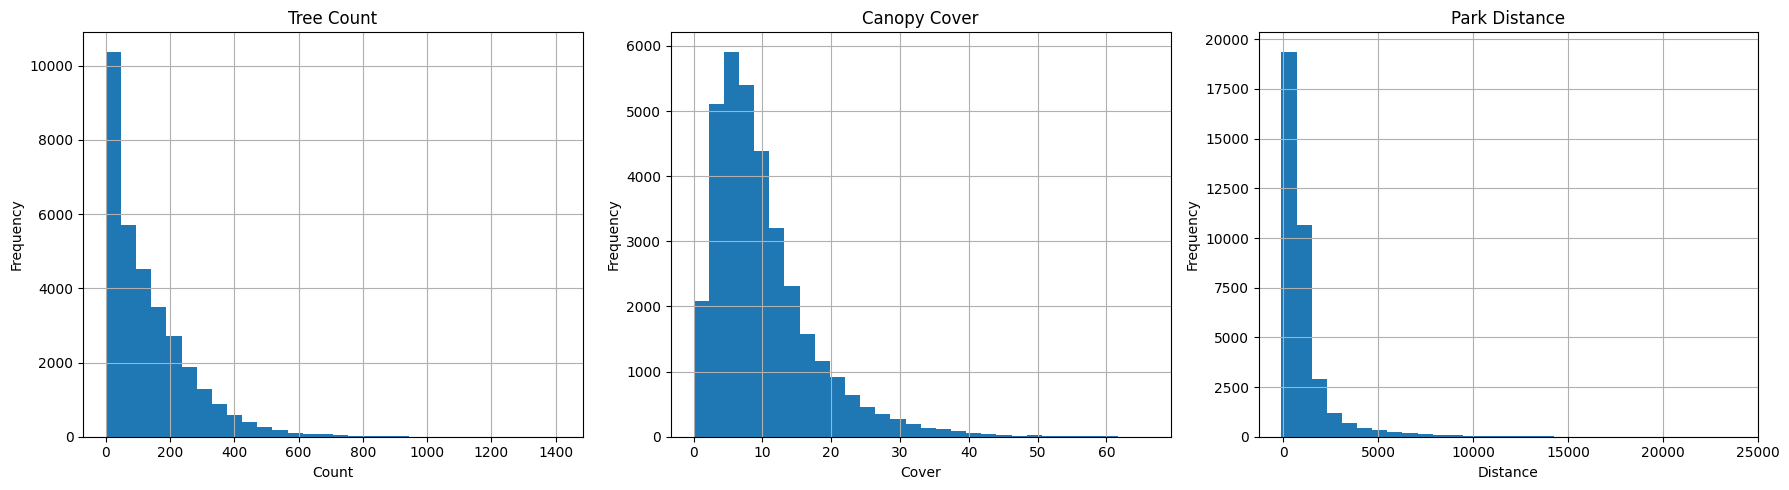

In [8]:
# Create histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

t3_30_300_gdf['tree_count'].hist(ax=axes[0], bins=30)
axes[0].set_title('Tree Count')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Frequency')

t3_30_300_gdf['canopy_cover'].hist(ax=axes[1], bins=30)
axes[1].set_title('Canopy Cover')
axes[1].set_xlabel('Cover')
axes[1].set_ylabel('Frequency')

t3_30_300_gdf['park_distance'].hist(ax=axes[2], bins=30)
axes[2].set_title('Park Distance')
axes[2].set_xlabel('Distance')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
T3_30_300_DIR = VECTOR_OUT_DIR / "3-30-300"
T3_dir = T3_30_300_DIR / "T3"
T30_dir = T3_30_300_DIR / "T30"
T300_dir = T3_30_300_DIR / "T300"
t3_30_300_path = T3_30_300_DIR / "T3_30_300.geojson"
imd_lsoa_bua_boundaries_path = VECTOR_OUT_DIR / "IMD" / "English_IMD_2019_BUA_filtered_boundaries.geojson"
imd_england_path = VECTOR_IN_DIR / "IMD" / "English IMD 2019" / "IMD_2019.shp"
buildings_path = VECTOR_IN_DIR / "EDINA" / "Buildings_6183" / "Buildings_6183.parquet"
spectral_indexes_path = T3_30_300_DIR / "spectral_indexes.geojson"
log_path = Path("logs/3-30-300_aggregate.log")

imd_lsoa_bua_gdf = gpd.read_file(imd_lsoa_bua_boundaries_path).sort_values(by='RGN22CD').drop_duplicates(subset='LSOA11CD', keep='first')
imd_england_columns = ['lsoa11cd', 'TotPop', 'DepChi', 'Pop16_59', 'Pop60+', 'WorkPop',
                    'IMD_Rank', 'IMD_Decile', 'IMDScore', 'IncScore', 'IncRank', 'IncDec', 
                    'EmpScore', 'EmpRank', 'EmpDec', 'EduScore', 'EduRank', 'EduDec', 
                    'HDDScore', 'HDDRank', 'HDDDec', 'CriScore', 'CriRank', 'CriDec', 
                    'BHSScore', 'BHSRank', 'BHSDec', 'EnvScore', 'EnvRank', 'EnvDec']
imd_england_gdf = gpd.read_file(imd_england_path)[imd_england_columns].rename(columns={'lsoa11cd': 'LSOA11CD_imd'})
spectral_indexes_gdf = gpd.read_file(spectral_indexes_path)

os.environ["JAVA_HOME"] = JAVA_HOME
sedona = get_spark()

# create_schemas(sedona, imd_lsoa_bua_gdf, imd_england_gdf, spectral_indexes_gdf, buildings_path, T3_dir, T30_dir, T300_dir)


25/01/24 23:13:14 WARN Utils: Your hostname, kinabalu resolves to a loopback address: 127.0.1.1; using 128.232.93.1 instead (on interface eno12399np0)
25/01/24 23:13:14 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
https://artifacts.unidata.ucar.edu/repository/unidata-all added as a remote repository with the name: repo-1
Ivy Default Cache set to: /home/acz25/.ivy2/cache
The jars for the packages stored in: /home/acz25/.ivy2/jars
org.apache.sedona#sedona-spark-3.5_2.12 added as a dependency
org.datasyslab#geotools-wrapper added as a dependency
net.postgis#postgis-jdbc added as a dependency
net.postgis#postgis-geometry added as a dependency
org.postgresql#postgresql added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-ba24689b-1694-4bcc-9dee-2a41c611cf85;1.0
	confs: [default]


:: loading settings :: url = jar:file:/maps-priv/maps/acz25/miniconda3/envs/3-30-300-env/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found org.apache.sedona#sedona-spark-3.5_2.12;1.7.0 in central
	found org.apache.sedona#sedona-common;1.7.0 in central
	found org.apache.commons#commons-math3;3.6.1 in central
	found org.locationtech.jts#jts-core;1.20.0 in central
	found org.wololo#jts2geojson;0.16.1 in central
	found org.locationtech.spatial4j#spatial4j;0.8 in central
	found com.google.geometry#s2-geometry;2.0.0 in central
	found com.google.guava#guava;25.1-jre in central
	found com.google.code.findbugs#jsr305;3.0.2 in central
	found org.checkerframework#checker-qual;2.0.0 in central
	found com.google.errorprone#error_prone_annotations;2.1.3 in central
	found com.google.j2objc#j2objc-annotations;1.1 in central
	found org.codehaus.mojo#animal-sniffer-annotations;1.14 in central
	found com.uber#h3;4.1.1 in central
	found net.sf.geographiclib#GeographicLib-Java;1.52 in central
	found com.github.ben-manes.caffeine#caffeine;2.9.2 in central
	found org.checkerframework#checker-qual;3.10.0 in central
	found com.google.error

In [23]:
imd_england_gdf = gpd.read_file(imd_england_path)[imd_england_columns].rename(columns={'lsoa11cd': 'LSOA11CD_imd'})

In [24]:
boundaries_sdf = sedona.createDataFrame(imd_lsoa_bua_gdf.drop(columns=['LSOA21NMW', 'LAD22NMW', 'BUA22NMG', 'BUA22NMW', 'RGN22NMW'], axis=1))
boundaries_sdf.createOrReplaceTempView('boundaries')
imd_england_sdf = sedona.createDataFrame(imd_england_gdf)
imd_england_sdf.createOrReplaceTempView('imd_england')
buildings_sdf = sedona.read.format("geoparquet").load(str(buildings_path))
buildings_sdf.createOrReplaceTempView("buildings")
spectral_indexes_sdf = sedona.createDataFrame(spectral_indexes_gdf)
spectral_indexes_sdf.createOrReplaceTempView("spectral_indexes")

t3_sdf = sedona.read.csv(str(T3_dir), header=True, inferSchema=True)
t3_sdf.createOrReplaceTempView("t3")
t30_sdf = sedona.read.csv(str(T30_dir), header=True, inferSchema=True)
t30_sdf.createOrReplaceTempView("t30")
t300_sdf = sedona.read.csv(str(T300_dir), header=True, inferSchema=True)
t300_sdf.createOrReplaceTempView("t300")

In [4]:
t3_30_300_sdf = run_queries(sedona)
t3_30_300_sdf.printSchema()

AnalysisException: [AMBIGUOUS_REFERENCE] Reference `t30_imd_lsoa`.`LSOA11CD` is ambiguous, could be: [`t30_imd_lsoa`.`LSOA11CD`, `t30_imd_lsoa`.`LSOA11CD`].; line 3 pos 30

In [22]:
t30_imd_lsoa_sdf.printSchema()

root
 |-- LSOA11CD: string (nullable = true)
 |-- LSOA11NM: string (nullable = true)
 |-- LSOA21CD: string (nullable = true)
 |-- LSOA21NM: string (nullable = true)
 |-- LAD22CD: string (nullable = true)
 |-- LAD22NM: string (nullable = true)
 |-- BUA22CD: string (nullable = true)
 |-- BUA22NM: string (nullable = true)
 |-- RGN22CD: string (nullable = true)
 |-- RGN22NM: string (nullable = true)
 |-- geometry: geometry (nullable = true)
 |-- area: double (nullable = true)
 |-- LSOA11CD: string (nullable = true)
 |-- TotPop: long (nullable = true)
 |-- DepChi: long (nullable = true)
 |-- Pop16_59: long (nullable = true)
 |-- Pop60+: long (nullable = true)
 |-- WorkPop: double (nullable = true)
 |-- IMD_Rank: long (nullable = true)
 |-- IMD_Decile: long (nullable = true)
 |-- IMDScore: double (nullable = true)
 |-- IncScore: double (nullable = true)
 |-- IncRank: long (nullable = true)
 |-- IncDec: long (nullable = true)
 |-- EmpScore: double (nullable = true)
 |-- EmpRank: long (nullabl

In [ ]:
buildings_lsoa_sdf = sedona.sql(
"""
SELECT b.*, l.LSOA11CD
FROM buildings b
JOIN boundaries l
ON ST_Contains(l.geometry, b.geometry)
"""
)
buildings_lsoa_sdf.createOrReplaceTempView("buildings2")

t30_imd_lsoa_sdf = sedona.sql(
"""
SELECT b.*, ROUND(ST_Area(b.geometry), 2) AS area, i.*, t.canopy_cover
FROM boundaries b
LEFT JOIN imd_england i ON b.LSOA11CD = i.LSOA11CD_imd
LEFT JOIN t30 t ON b.LSOA11CD = t.LSOA11CD
"""
)
t30_imd_lsoa_sdf = t30_imd_lsoa_sdf.drop("LSOA11CD_imd")
t30_imd_lsoa_sdf.createOrReplaceTempView("t30_imd_lsoa")

t3_300_building_sdf = sedona.sql(
"""
SELECT b.*, t3.tree_count, t300.closest_park_access_id, t300.distance
FROM buildings2 b
LEFT JOIN t3 ON b.verisk_premise_id = t3.verisk_premise_id
LEFT JOIN t300 ON b.verisk_premise_id = t300.verisk_premise_id
"""
)
t3_300_building_sdf.createOrReplaceTempView("t3_300_building")

t3_300_lsoa_sdf = sedona.sql(
"""
SELECT LSOA11CD, ROUND(AVG(tree_count), 2) as tree_count, ROUND(AVG(distance), 2) as park_distance, ROUND(AVG(distance_water), 2) as water_distance
FROM t3_300_building
GROUP BY LSOA11CD
"""
)
t3_300_lsoa_sdf.createOrReplaceTempView("t3_300_lsoa")

t3_30_300_sdf = sedona.sql(
"""
SELECT a.*, b.tree_count, b.park_distance, b.water_distance FROM t30_imd_lsoa a 
INNER JOIN t3_300_lsoa b ON a.LSOA11CD = b.LSOA11CD
""")
t3_30_300_sdf.createOrReplaceTempView("t3_30_300")
t3_30_300_sdf = sedona.sql(
"""
SELECT *, (TotPop / area) AS TotPop_density,
(DepChi / TotPop) AS DepChi_ratio,
(Pop16_59 / TotPop) AS Pop16_59_ratio,
(`Pop60+` / TotPop) AS Pop60_ratio,
(WorkPop / TotPop) AS WorkPop_ratio
FROM t3_30_300 
"""
)

In [39]:
# Calculate total F and total M
population_estimates_df['Total_F'] = population_estimates_df[['F0_to_15', 'F16_to_29', 'F30_to_44', 'F45_to_64', 'F65_and_over']].sum(axis=1)
population_estimates_df['Total_M'] = excel_data2[['M0_to_15', 'M16_to_29', 'M30_to_44', 'M45_to_64', 'M65_and_over']].sum(axis=1)

# Calculate total per age range
excel_data2['Total_0_to_15'] = excel_data2[['F0_to_15', 'M0_to_15']].sum(axis=1)
excel_data2['Total_16_to_29'] = excel_data2[['F16_to_29', 'M16_to_29']].sum(axis=1)
excel_data2['Total_30_to_44'] = excel_data2[['F30_to_44', 'M30_to_44']].sum(axis=1)
excel_data2['Total_45_to_64'] = excel_data2[['F45_to_64', 'M45_to_64']].sum(axis=1)
excel_data2['Total_65_and_over'] = excel_data2[['F65_and_over', 'M65_and_over']].sum(axis=1)

excel_data2.head()

Index(['LAD_2021_Code', 'LAD_2021_Name', 'LSOA_2021_Code', 'LSOA_2021_Name',
       'Total', 'F0_to_15', 'F16_to_29', 'F30_to_44', 'F45_to_64',
       'F65_and_over', 'M0_to_15', 'M16_to_29', 'M30_to_44', 'M45_to_64',
       'M65_and_over'],
      dtype='object')

In [44]:
# Define the path to the Excel file
population_estimates_path = TABULAR_IN_DIR / "ONS" / "sapelsoabroadage20112022.xlsx"
population_estimates_df = pd.read_excel(population_estimates_path, sheet_name='Mid-2022 LSOA 2021', skiprows=3)
population_estimates_df.columns = excel_data2.columns.str.replace(' ', '_')
# Calculate the ratio of each column compared to Total
columns_to_calculate = ['F0_to_15', 'F16_to_29', 'F30_to_44', 'F45_to_64', 'F65_and_over', 
                        'M0_to_15', 'M16_to_29', 'M30_to_44', 'M45_to_64', 'M65_and_over']
for column in columns_to_calculate:
    population_estimates_df[f'{column}_ratio'] = population_estimates_df[column] / population_estimates_df['Total']

# Calculate the ratio of total F and total M
population_estimates_df['Total_F'] = population_estimates_df[['F0_to_15', 'F16_to_29', 'F30_to_44', 'F45_to_64', 'F65_and_over']].sum(axis=1)
population_estimates_df['Total_M'] = population_estimates_df[['M0_to_15', 'M16_to_29', 'M30_to_44', 'M45_to_64', 'M65_and_over']].sum(axis=1)
population_estimates_df['F_ratio'] = population_estimates_df['Total_F'] / population_estimates_df['Total']
population_estimates_df['M_ratio'] = population_estimates_df['Total_M'] / population_estimates_df['Total']

# Calculate the ratio per age range
age_ranges = ['0_to_15', '16_to_29', '30_to_44', '45_to_64', '65_and_over']
for age_range in age_ranges:
    population_estimates_df[f'{age_range}_ratio'] = population_estimates_df[f'F{age_range}'] + population_estimates_df[f'M{age_range}']
    population_estimates_df[f'{age_range}_ratio'] /= population_estimates_df['Total']

# Keep only the required columns
columns_to_keep = ['LSOA_2021_Code', 'Total'] + [col for col in population_estimates_df.columns if col.endswith('_ratio')]
population_estimates_df = population_estimates_df[columns_to_keep]
population_estimates_df

,LSOA_2021_Code,Total,F0_to_15_ratio,F16_to_29_ratio,F30_to_44_ratio,F45_to_64_ratio,F65_and_over_ratio,M0_to_15_ratio,M16_to_29_ratio,M30_to_44_ratio,M45_to_64_ratio,M65_and_over_ratio,F_ratio,M_ratio,0_to_15_ratio,16_to_29_ratio,30_to_44_ratio,45_to_64_ratio,65_and_over_ratio
0,E01011949,1870,0.098930,0.091979,0.096257,0.142246,0.093048,0.103743,0.093583,0.083957,0.126738,0.069519,0.522460,0.477540,0.202674,0.185561,0.180214,0.268984,0.162567
1,E01011950,1097,0.092069,0.072926,0.093892,0.127621,0.087511,0.092069,0.084777,0.123063,0.152233,0.073838,0.474020,0.525980,0.184139,0.157703,0.216955,0.279854,0.161349
2,E01011951,1241,0.076551,0.100725,0.115230,0.134569,0.074134,0.101531,0.078163,0.111201,0.151491,0.056406,0.501209,0.498791,0.178082,0.178888,0.226430,0.286060,0.130540
3,E01011952,1615,0.117647,0.079876,0.096594,0.128793,0.121362,0.116409,0.066873,0.061920,0.126935,0.083591,0.544272,0.455728,0.234056,0.146749,0.158514,0.255728,0.204954
4,E01011953,1982,0.108981,0.110999,0.095863,0.118567,0.070131,0.145812,0.090817,0.080727,0.115035,0.063068,0.504541,0.495459,0.254793,0.201816,0.176589,0.233602,0.133199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35667,W01001324,1896,0.078586,0.066456,0.087553,0.145570,0.139768,0.072785,0.069093,0.082806,0.135549,0.121835,0.517932,0.482068,0.151371,0.135549,0.170359,0.281118,0.261603
35668,W01001898,1444,0.090028,0.066482,0.101801,0.155125,0.108033,0.072715,0.075485,0.080332,0.146814,0.103186,0.521468,0.478532,0.162742,0.141967,0.182133,0.301939,0.211219
35669,W01001959,1550,0.090968,0.075484,0.122581,0.142581,0.075484,0.115484,0.070968,0.097419,0.129677,0.079355,0.507097,0.492903,0.206452,0.146452,0.220000,0.272258,0.154839
35670,W01001960,1476,0.090786,0.077236,0.107724,0.117886,0.105691,0.086721,0.083333,0.112466,0.134146,0.084011,0.499322,0.500678,0.177507,0.160569,0.220190,0.252033,0.189702
